In [5]:
import os

print(os.listdir(r"D:\DA INTERN\da vs"))

['Customer_Behavior_Analysis', 'Sales performance analysis', 'web_traffic.csv']


In [6]:
import os

for root, dirs, files in os.walk(r"D:\DA INTERN\da vs"):
    for file in files:
        if file.endswith(".csv"):
            print(os.path.join(root, file))

D:\DA INTERN\da vs\web_traffic.csv
D:\DA INTERN\da vs\Customer_Behavior_Analysis\ecommerce_customer_data_custom_ratios.csv
D:\DA INTERN\da vs\Customer_Behavior_Analysis\ecommerce_customer_data_large.csv
D:\DA INTERN\da vs\Sales performance analysis\SuperStoreOrders.csv


In [7]:
import pandas as pd

df = pd.read_csv(r"D:\DA INTERN\da vs\web_traffic.csv")

df.head()

,Timestamp,TrafficCount
0,2020-01-20 00:00:00,487.0
1,2020-01-20 00:30:00,385.0
2,2020-01-20 01:30:00,269.0
3,2020-01-20 02:30:00,517.0
4,2020-01-20 03:30:00,129.0


In [8]:
print("Shape:", df.shape)

df.info()

df.describe()

df.isnull().sum()

Shape: (2793, 2)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2793 entries, 0 to 2792
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Timestamp     2793 non-null   object 
 1   TrafficCount  2793 non-null   float64
dtypes: float64(1), object(1)
memory usage: 43.8+ KB


Timestamp       0
TrafficCount    0
dtype: int64

In [9]:
df['Timestamp'] = pd.to_datetime(df['Timestamp'])

df['Date'] = df['Timestamp'].dt.date
df['Hour'] = df['Timestamp'].dt.hour
df['Day'] = df['Timestamp'].dt.day_name()

print(df.head())

            Timestamp  TrafficCount        Date  Hour     Day
0 2020-01-20 00:00:00         487.0  2020-01-20     0  Monday
1 2020-01-20 00:30:00         385.0  2020-01-20     0  Monday
2 2020-01-20 01:30:00         269.0  2020-01-20     1  Monday
3 2020-01-20 02:30:00         517.0  2020-01-20     2  Monday
4 2020-01-20 03:30:00         129.0  2020-01-20     3  Monday


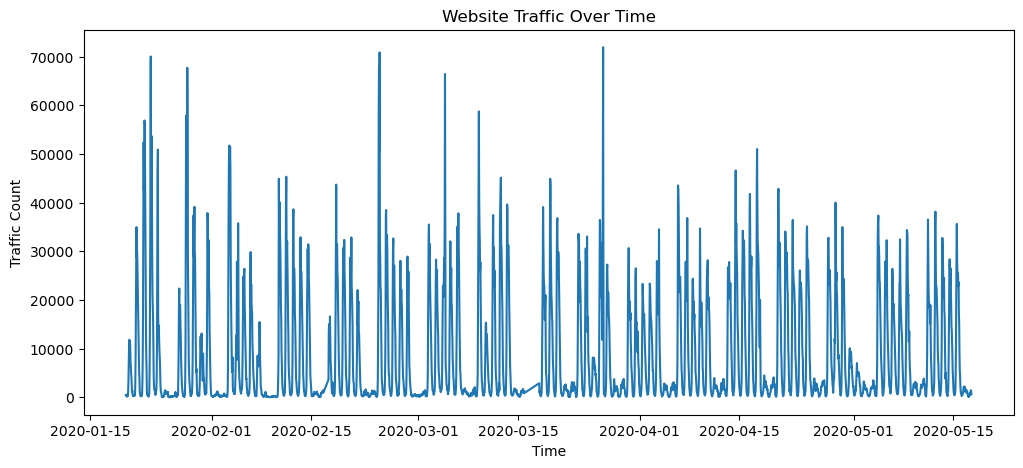

In [10]:
plt.figure(figsize=(12,5))

plt.plot(df['Timestamp'], df['TrafficCount'])

plt.title("Website Traffic Over Time")
plt.xlabel("Time")
plt.ylabel("Traffic Count")

plt.show()

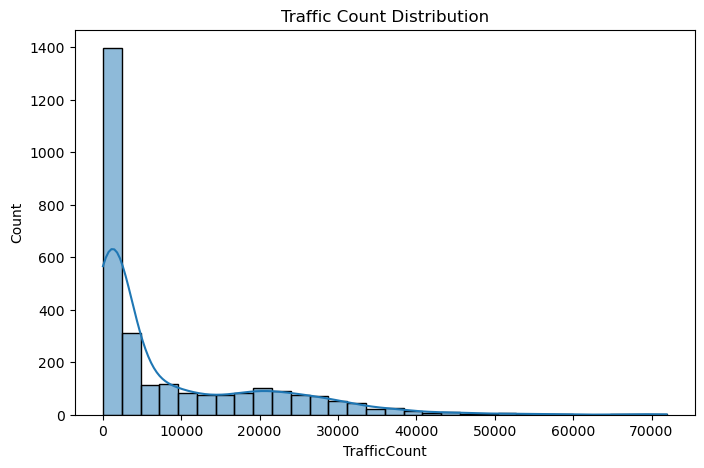

In [11]:
plt.figure(figsize=(8,5))

sns.histplot(df['TrafficCount'], bins=30, kde=True)

plt.title("Traffic Count Distribution")

plt.show()

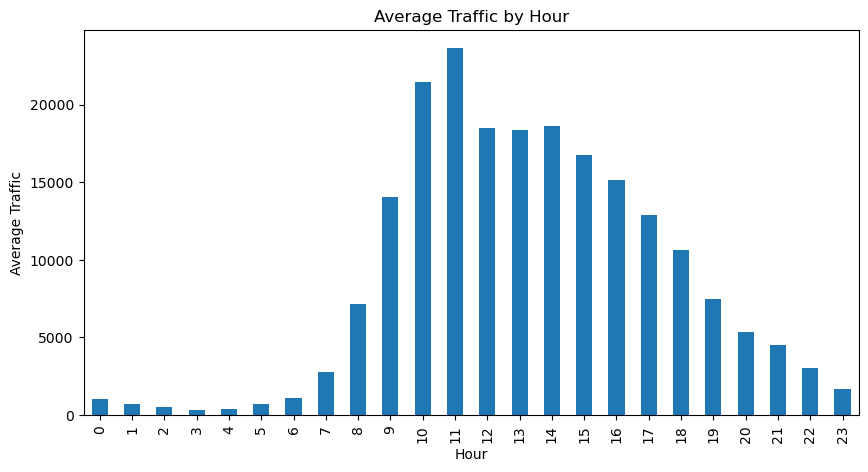

In [12]:
hourly = df.groupby('Hour')['TrafficCount'].mean()

plt.figure(figsize=(10,5))

hourly.plot(kind='bar')

plt.title("Average Traffic by Hour")
plt.ylabel("Average Traffic")

plt.show()

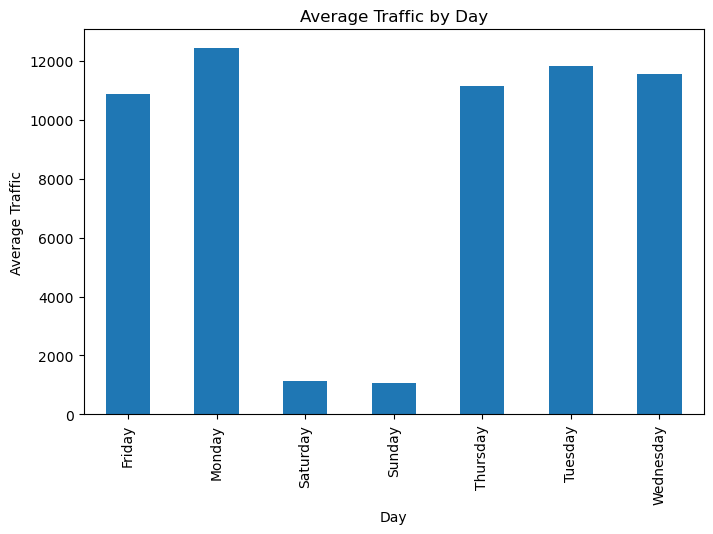

In [13]:
daily = df.groupby('Day')['TrafficCount'].mean()

plt.figure(figsize=(8,5))

daily.plot(kind='bar')

plt.title("Average Traffic by Day")

plt.ylabel("Average Traffic")

plt.show()

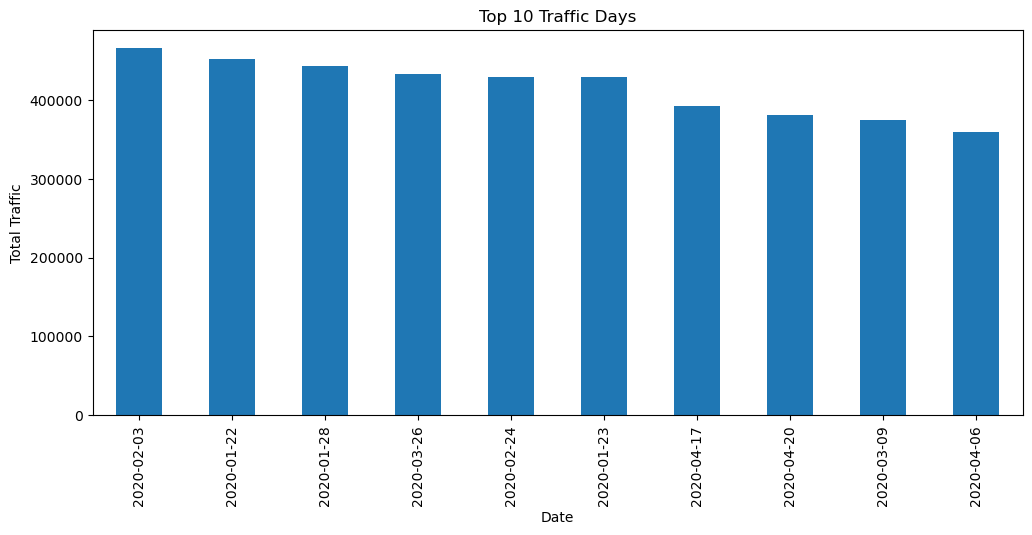

In [14]:
daily_total = df.groupby('Date')['TrafficCount'].sum()

top_days = daily_total.sort_values(ascending=False).head(10)

plt.figure(figsize=(12,5))

top_days.plot(kind='bar')

plt.title("Top 10 Traffic Days")

plt.ylabel("Total Traffic")

plt.show()

In [15]:
print("Maximum Traffic:", df['TrafficCount'].max())

print("Minimum Traffic:", df['TrafficCount'].min())

print("Average Traffic:", round(df['TrafficCount'].mean(),2))

print("Median Traffic:", round(df['TrafficCount'].median(),2))

Maximum Traffic: 71925.0
Minimum Traffic: 22.0
Average Traffic: 8591.32
Median Traffic: 2418.0
